<a href="https://colab.research.google.com/github/l22140161-dotcom/Analisis-y-visualizacion-de-datos/blob/main/Guia_U5_DDDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

R — Plantilla de análisis exploratorio (EDA)

Rows: 1200 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): fecha, zona
dbl (1): monto

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 1,200
Columns: 3
$ fecha <chr> "01/01/2025", "01/01/2025", "02/01/2025", "03/01/2025", "03/01/2…
$ zona  <chr> "Norte", "Centro", "Centro", "Norte", "Norte", "Oriente", "Norte…
$ monto <dbl> 65.0, 36.1, 47.5, 90.0, 180.0, 176.0, 76.0, 80.0, 176.0, 90.0, 1…


       fecha             zona          monto       
 Length   :1200   Length   :1200   Min.   : 25.20  
 N.unique : 345   N.unique :   5   1st Qu.: 50.00  
 N.blank  :   0   N.blank  :   0   Median : 76.00  
 Min.nchar:  10   Min.nchar:   3   Mean   : 99.89  
 Max.nchar:  10   Max.nchar:   9   3rd Qu.:125.00  
                                   Max.   :625.00  

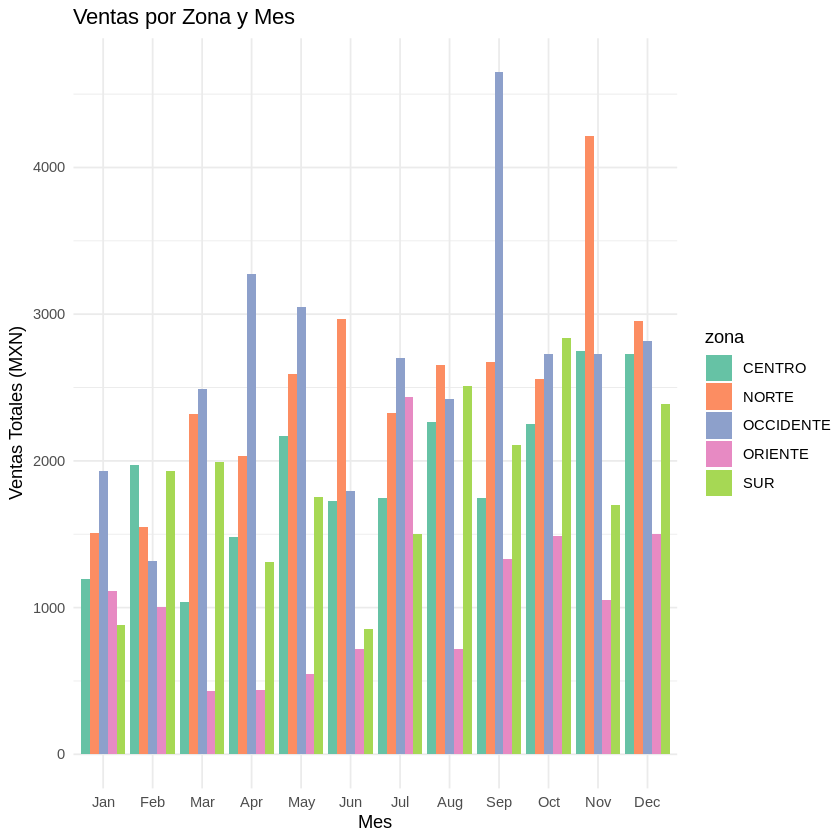

In [2]:
library(tidyverse)
library(lubridate)

# 1. Importar datos
datos <- read_csv('ventas.csv')

# 2. Explorar estructura
glimpse(datos)
summary(datos)

# 3. Limpiar y transformar
datos_limpios <- datos |>
  drop_na(monto) |>
  mutate(fecha = dmy(fecha),
         mes   = month(fecha, label = TRUE),
         zona  = str_to_upper(zona))

# 4. Agregar KPIs
resumen <- datos_limpios |>
  group_by(zona, mes) |>
  summarise(total = sum(monto),
            tickets = n(),
            ticket_prom = mean(monto), .groups = 'drop')

# 5. Visualizar
ggplot(resumen, aes(x = mes, y = total, fill = zona)) +
  geom_col(position = 'dodge') +
  labs(title = 'Ventas por Zona y Mes',
       x = 'Mes', y = 'Ventas Totales (MXN)') +
  theme_minimal() +
  scale_fill_brewer(palette = 'Set2')


 R — Simulación Monte Carlo simple

Utilidad media esperada: $ 179054 
Probabilidad de pérdida: 2.93 %
IC 95%: [$ -7496 , $ 370234 ]


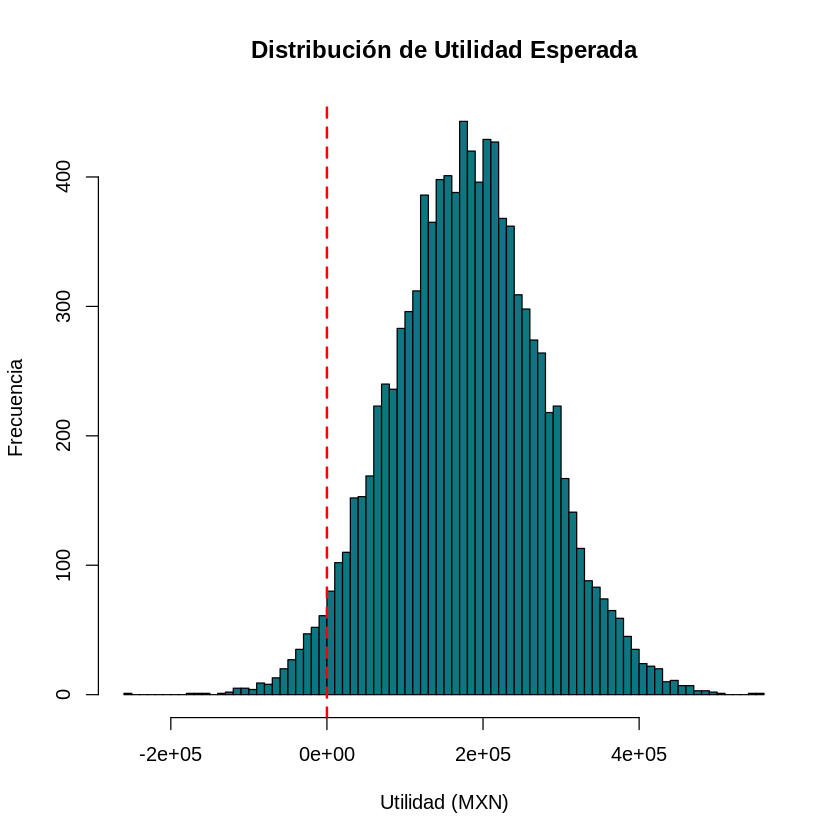

In [3]:
set.seed(42)
n_sim <- 10000
# Simular ingresos y costos con incertidumbre
ingresos <- rnorm(n_sim, mean = 500000, sd = 80000)
costos   <- rnorm(n_sim, mean = 320000, sd = 50000)
utilidad <- ingresos - costos

# Resultados
cat('Utilidad media esperada: $', round(mean(utilidad), 0), '\n')
cat('Probabilidad de pérdida:', mean(utilidad < 0) * 100, '%\n')
cat('IC 95%: [$', round(quantile(utilidad, 0.025), 0),
    ', $', round(quantile(utilidad, 0.975), 0), ']\n')

# Histograma de resultados
hist(utilidad, breaks = 60, col = '#0D7680',
     main = 'Distribución de Utilidad Esperada',
     xlab = 'Utilidad (MXN)', ylab = 'Frecuencia')
abline(v = 0, col = 'red', lwd = 2, lty = 2)
